# Lab 1 — Artificial Neural Networks & Gradient Descent (Hands-on)

**Course:** Solutions in Pattern Recognition  

### What you'll learn
- See **linear regression** as the simplest neural network (no hidden layers, one output neuron).
- Generate synthetic data and **visualize** predictions.
- Understand **Mean Squared Error (MSE)** as a "wrongness" score.
- Train a line with **Gradient Descent (GD)** and **watch the loss go down**.

> Tip: Keep the math light. Focus on *what changes* when you adjust settings like the learning rate.


## 0. Setup
Import the libraries used in this lab:
- **NumPy** for data and calculations  
- **Matplotlib** for plots




In [2]:

import numpy as np
import matplotlib.pyplot as plt

# Ensure plots display inline (Jupyter)
%matplotlib inline

# For reproducibility
rng = np.random.default_rng(42)


## 1. Generate Synthetic Data
We'll simulate a line with noise:
- Choose a true slope `w_true` and intercept `b_true`.
- Add random noise so the points don't sit perfectly on a line.

**Goal:** create a realistic dataset to train on.


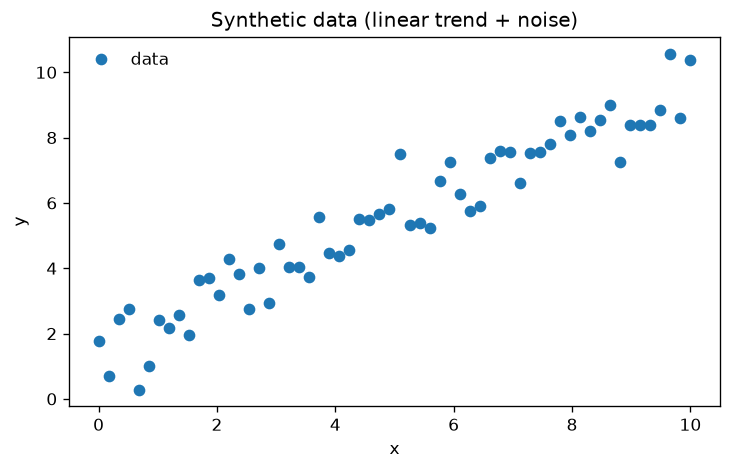

In [3]:

# True parameters and data
n = 60
x = np.linspace(0, 10, n)
w_true, b_true = 0.8, 1.5
noise = rng.normal(0, 0.9, size=n)
y = w_true * x + b_true + noise

# Visualize data
fig, ax = plt.subplots(figsize=(7,4), dpi=120)
ax.plot(x, y, linestyle="", marker="o", label="data")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Synthetic data (linear trend + noise)")
ax.legend(frameon=False, loc="upper left")
plt.show()


## 2. Linear Regression as a Neural Network
The simplest neural network has:
- **No hidden layers**
- **One output neuron** with a **linear activation**

We predict with a line:  
$$
\hat{y} = wx + b
$$


**Goal:** Plot the data and overlay a line to build intuition.


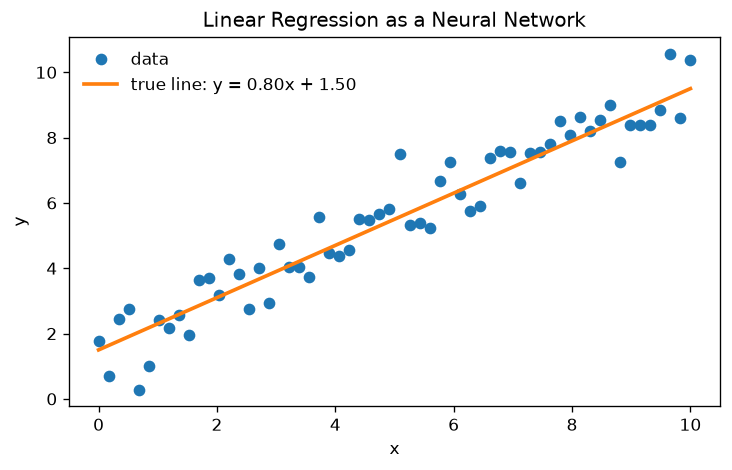

In [4]:

def predict(w, b, x):
    return w * x + b

# Quick demo with true parameters
fig, ax = plt.subplots(figsize=(7,4), dpi=120)
ax.plot(x, y, linestyle="", marker="o", label="data")
xs = np.linspace(x.min(), x.max(), 200)
ax.plot(xs, predict(w_true, b_true, xs), linewidth=2.2, label=f"true line: y = {w_true:.2f}x + {b_true:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Linear Regression as a Neural Network")
ax.legend(frameon=False, loc="upper left")
plt.show()


## 3. Loss Function — Mean Squared Error (MSE)
We measure how wrong predictions are using **MSE** — the average of squared vertical distances between points and the line.
$$
\mathrm{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- We'll start from a **random guess**
$$
(w_0, b_0)
$$.
- We'll **draw the residuals** (vertical dotted lines) to see the errors.
- **Smaller MSE = better fit.**


In [4]:

# Random initial guess
w0 = rng.normal(0, 1)
b0 = rng.normal(0, 1)

def mse(w, b, x, y):
    yhat = predict(w, b, x)
    return np.mean((y - yhat)**2)

# Compute and show initial MSE
mse0 = mse(w0, b0, x, y)
print(f"Initial guess -> w0: {w0:.3f}, b0: {b0:.3f}, MSE: {mse0:.3f}")

# Plot with residuals
fig, ax = plt.subplots(figsize=(7,4), dpi=120)
ax.plot(x, y, linestyle="", marker="o", label="data")
ax.plot(xs, predict(w0, b0, xs), linewidth=2.2, label=f"guess: y = {w0:.2f}x + {b0:.2f}")

yhat0 = predict(w0, b0, x)
for xi, yi, yhi in zip(x, y, yhat0):
    ax.vlines(xi, min(yi, yhi), max(yi, yhi), linestyles="dashed", linewidth=1.0)

ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Initial guess and residuals")
ax.legend(frameon=False, loc="upper left")
plt.show()


NameError: name 'rng' is not defined

## 4. Gradient Descent (Batch)
**Training loop (no heavy math):**
1. Make predictions with current \(w, b\).
2. Compute the **error** for all points.
3. Nudge \(w, b\) a little to make the error **smaller** next time.
4. Repeat many small steps.

**Learning rate (`lr`) controls step size:**
- Too small → slow learning  
- Too big → unstable / overshoots  
- Just right → smooth, fast learning

We'll record the path of (w, b) and the **loss over iterations**.


In [ ]:

def gradients(w, b, x, y):
    yhat = predict(w, b, x)
    e = yhat - y
    dw = 2.0 * np.mean(x * e)
    db = 2.0 * np.mean(e)
    return dw, db

# Hyperparameters
lr = 0.02     # learning rate
steps = 200   # iterations

# Initialize
w, b = float(w0), float(b0)
history_w, history_b, history_loss = [w], [b], [mse(w, b, x, y)]

for _ in range(steps):
    dw, db = gradients(w, b, x, y)
    w -= lr * dw
    b -= lr * db
    history_w.append(w); history_b.append(b); history_loss.append(mse(w, b, x, y))

print(f"After GD -> w: {w:.3f}, b: {b:.3f}, MSE: {history_loss[-1]:.3f}")


After GD -> w: 0.846, b: 1.281, MSE: 0.498



## 5. Visualizing Training Progress
We'll look at two views:
- **Loss vs. iteration**: a single curve that should go **down** over time.
- **Model snapshots**: compare the line at **start**, **middle**, and **end** of training.

**What to look for**
- A steady decrease in loss (some bumps are normal).
- The line should clearly fit the data better by the end.


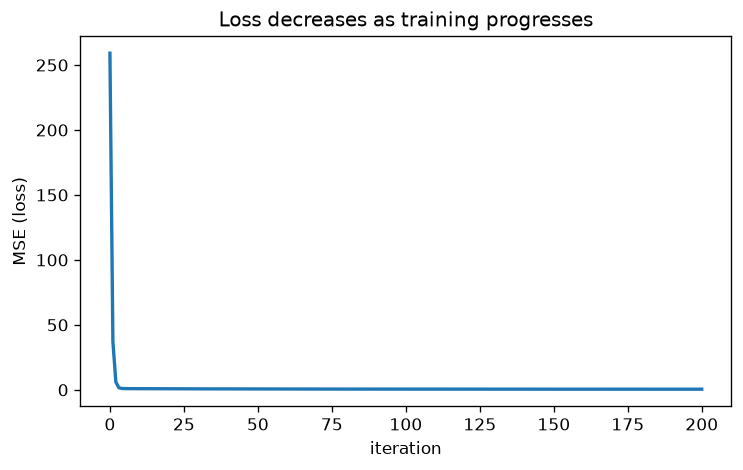

In [ ]:

fig, ax = plt.subplots(figsize=(7,4), dpi=120)
ax.plot(np.arange(len(history_loss)), history_loss, linewidth=2.0)
ax.set_xlabel("iteration")
ax.set_ylabel("MSE (loss)")
ax.set_title("Loss decreases as training progresses")
plt.show()


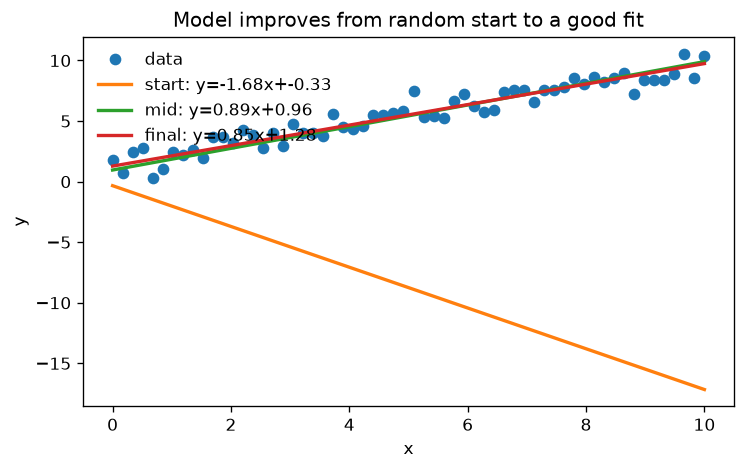

In [ ]:

fig, ax = plt.subplots(figsize=(7,4), dpi=120)
ax.plot(x, y, linestyle="", marker="o", label="data")

# pick 3 checkpoints
idxs = [0, len(history_w)//2, len(history_w)-1]
labels = ["start", "mid", "final"]

for i, lbl in zip(idxs, labels):
    ax.plot(xs, predict(history_w[i], history_b[i], xs), linewidth=2.0, label=f"{lbl}: y={history_w[i]:.2f}x+{history_b[i]:.2f}")

ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Model improves from random start to a good fit")
ax.legend(frameon=False, loc="upper left")
plt.show()


## 6. Mini-Exercises (Try & Observe)
1. **Change the learning rate `lr`** (e.g., `0.001`, `0.02`, `0.2`).  
   - *Expected:* too small → slow; too large → unstable. Find a sweet spot.
2. **Increase noise** in data generation (e.g., `noise = rng.normal(0, 1.5, size=n)`).  
   - *Observe:* How do the final line and MSE change?
3. **Feature scaling** (advanced): standardize \(x\) (subtract mean, divide by std) and repeat GD.  
   - *Observe:* Does learning become smoother/faster?
4. **Different starting points**: set `w0, b0` to extreme values and re-run training.  
   - *Observe:* How does the loss curve differ?


## 7. Neural Network Implementation using PyTorch (Optional)
This optional section mirrors the same ideas using **PyTorch**:
- Define a tiny model with one linear layer (this is
  $$
  \hat{y} = wx + b
  $$).
- Use a built-in optimizer to update \(w, b\).
- Plot the loss to confirm it **decreases over time**.

**Why do this?**  
It shows how the exact same learning loop looks in a deep learning framework you'll use later.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# x, y from the notebook's synthetic data (convert to tensors)
x_tensor = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# Define neural network model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super(LinearRegressionNN, self).__init__()
        self.linear = nn.Linear(1, 1)  # Single linear layer (neuron)

    def forward(self, x):
        return self.linear(x)  # ŷ = w x + b (no activation)

# Instantiate model, loss, and optimizer
model = LinearRegressionNN()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
epochs = 1000
history_w, history_b = [], []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x_tensor)
    loss = criterion(y_pred, y_tensor)
    loss.backward()
    optimizer.step()

    # Track parameters (w, b)
    history_w.append(model.linear.weight.item())
    history_b.append(model.linear.bias.item())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Final parameters
w_learned = model.linear.weight.item()
b_learned = model.linear.bias.item()
print(f'Learned: w = {w_learned:.2f}, b = {b_learned:.2f}')

# Plot (similar to notebook)
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(x, y, linestyle="", marker="o", label="data")
xs = np.linspace(x.min(), x.max(), 200)
ys = w_learned * xs + b_learned
ax.plot(xs, ys, linewidth=2.2, label=f"learned: y = {w_learned:.2f}x + {b_learned:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Linear Regression as a Neural Network (PyTorch)")
ax.legend(frameon=False, loc="upper left")
plt.show()